# Importing Necessary Packages

In [1]:
# ================================
# 📌 Essential Libraries for ML Workflow
# ================================

# 📊 Data Manipulation & Numerical Computation
import pandas as pd  # Efficient data handling & processing
import numpy as np  # Numerical operations & array manipulation

# 📈 Data Visualization
import matplotlib.pyplot as plt  # Basic plotting functions
import seaborn as sns  # Advanced & aesthetic statistical visualizations

# 🔍 Model Selection & Evaluation
from sklearn.model_selection import (
    train_test_split,  # Splitting dataset into training & validation sets
    cross_val_score,  # Evaluating model performance via cross-validation
    StratifiedKFold  # Ensuring class balance in K-Fold cross-validation
)

# ⚙️ Data Preprocessing
from sklearn.impute import SimpleImputer  # Handling missing values
from sklearn.preprocessing import StandardScaler  # Standardizing numerical features
from sklearn.preprocessing import OneHotEncoder  # Encoding categorical variables

# 🚀 Feature Engineering & Pipelines
from sklearn.pipeline import Pipeline  # Creating streamlined ML workflows
from sklearn.decomposition import PCA  # Dimensionality reduction
from sklearn.feature_selection import SelectKBest, chi2  # Selecting best features
from sklearn.compose import ColumnTransformer  # Handling multiple transformations efficiently

# 🏆 Machine Learning Models
from sklearn.linear_model import (
    LogisticRegression,  # Logistic Regression for classification
    SGDClassifier  # Stochastic Gradient Descent (SGD) classifier
)
from sklearn.ensemble import RandomForestClassifier  # Random Forest ensemble model

# 🚀 Gradient Boosting Models (Boosted Trees)
from xgboost import XGBClassifier  # XGBoost: High-performance gradient boosting
from lightgbm import LGBMClassifier  # LightGBM: Fast & efficient boosting

# 🔧 Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV  # Fine-tuning models for best performance


# Data Loading

In [2]:
train_data=pd.read_csv('/kaggle/input/System-Threat-Forecaster/train.csv')
test_data=pd.read_csv('/kaggle/input/System-Threat-Forecaster/test.csv')

In [3]:
# Set option to display all rows
pd.set_option('display.max_rows', None)

# Set option to display all columns
pd.set_option('display.max_columns', None)


In [4]:
train_data.head()

,MachineID,ProductName,EngineVersion,AppVersion,SignatureVersion,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,PlatformType,Processor,OSVersion,OSBuildNumber,OSProductSuite,OsPlatformSubRelease,OSBuildLab,SKUEditionName,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,MDC2FormFactor,DeviceFamily,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,PrimaryDiskType,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,ChassisType,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,PowerPlatformRole,InternalBatteryNumberOfCharges,NumericOSVersion,OSArchitecture,OSBranch,OSBuildNumberOnly,OSBuildRevisionOnly,OSEdition,OSSkuFriendlyName,OSInstallType,OSInstallLanguageID,OSUILocaleID,AutoUpdateOptionsName,IsPortableOS,OSGenuineState,LicenseActivationChannel,IsFlightsDisabled,FlightRing,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,DateAS,DateOS,target
0,f541bae429089117c4aac39c90dd3416,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1003.0,0,7.0,0,53447.0,1.0,1.0,1,51,120232.0,98.0,103,windows10,x86,10.0.0.0,14393,768,rs1,14393.2214.x86fre.rs1_release_1.180402-1758,Home,1.0,0,0.0,98.0,1.0,1.0,SmallTablet,Windows.Desktop,561.0,330367.0,4.0,5.0,1850.0,15028.0,SSD,14348.0,0,1024.0,Notebook,8.0,800.0,1280.0,Slate,1.420000e+02,10.0.14393.2214,x86,rs1_release,14393,2214,Core,CORE,Update,5.0,26,UNKNOWN,0,IS_GENUINE,Retail,0.0,Retail,513.0,21964.0,0,0.0,1,0,1.0,0.0,6.0,2018-09-10 10:11:00,2018-04-17,0
1,dc2b14d9ce3a0ce4050bb640190f2ca5,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1465.0,0,7.0,0,53447.0,1.0,1.0,1,141,112854.0,167.0,227,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,AllInOne,Windows.Desktop,2668.0,25212.0,4.0,5.0,2407.0,953869.0,HDD,952592.0,1,4096.0,AllinOne,19.4,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.228,amd64,rs4_release,17134,228,Professional,PROFESSIONAL,UUPUpgrade,9.0,34,FullAuto,0,IS_GENUINE,OEM:DM,0.0,Retail,628.0,44548.0,1,0.0,0,0,0.0,0.0,10.0,2018-08-16 00:01:00,2018-08-14,1
2,fd20c5f010e9c5f91ad1c6b3e0da68a0,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1546.0,0,7.0,0,53447.0,1.0,1.0,1,51,41759.0,98.0,103,windows10,x64,10.0.0.0,17134,768,rs4,17134.1.amd64fre.rs4_release.180410-1804,Home,1.0,0,0.0,137.0,1.0,1.0,Desktop,Windows.Desktop,3035.0,263666.0,4.0,5.0,2719.0,228936.0,SSD,228321.0,1,8192.0,Desktop,24.0,1920.0,1080.0,Desktop,4.294967e+09,10.0.17134.285,amd64,rs4_release,17134,285,Core,CORE,Reset,5.0,26,FullAuto,0,IS_GENUINE,OEM:NONSLP,0.0,Retail,142.0,9414.0,0,0.0,0,0,0.0,1.0,6.0,2018-09-20 23:20:00,2018-09-11,1
3,38711eae85eb77a72ec5dfdf27eb2a76,win8defender,1.1.15200.1,4.12.17007.18011,1.275.1141.0,0,7.0,0,46413.0,2.0,1.0,1,68,19507.0,276.0,74,windows10,x64,10.0.0.0,15063,768,rs2,15063.0.amd64fre.rs2_release.170317-1834,Home,1.0,0,0.0,108.0,1.0,1.0,Notebook,Windows.Desktop,2102.0,242491.0,4.0,5.0,3410.0,1907729.0,HDD,1890776.0,0,8192.0,Notebook,15.5,1366.0,768.0,Mobile,0.000000e+00,10.0.15063.850,amd64,rs2_release,15063,850,Core,CORE,Upgrade,7.0,30,UNKNOWN,0,IS_GENUINE,OEM:DM,0.0,Retail,554.0,33060.0,1,0.0,0,0,0.0,0.0,12.0,2018-09-14 00:32:00,2018-01-03,1
4,32607c9a543a9214e2c7e45800ed4849,win8defender,1.1.15200.1,4.13.17134.228,1.275.1283.0,0,7.0,0,40466.0,2.0,1.0,1,43,117801.0,53.0,42,windows10,x86,10.0.0.0,17134,256,rs4,17134.1.x86fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,Desktop,Windows.Desktop,2668.0,257309.0,2.0,5.0,4322.0,305245.0,HDD,52804.0,0,2048.0,Desktop,20.0,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.285,x86,rs4_release,17134,285,Professional,PROFESSIONAL,UUPUpgrade,37.0,158,FullAuto,0,IS_GENUINE,Retail,0.0,Retail,628.0

In [5]:
print(f"\033[1mShape of the training data is:\033[0m {train_data.shape}")

Shape of the training data is: (100000, 76)


# Data Exploration

In [6]:
# Examine data types
print("\033[1mData Types:\033[0m")
print(train_data.info())

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 76 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   MachineID                           100000 non-null  object 
 1   ProductName                         100000 non-null  object 
 2   EngineVersion                       100000 non-null  object 
 3   AppVersion                          100000 non-null  object 
 4   SignatureVersion                    100000 non-null  object 
 5   IsBetaUser                          100000 non-null  int64  
 6   RealTimeProtectionState             99934 non-null   float64
 7   IsPassiveModeEnabled                100000 non-null  int64  
 8   AntivirusConfigID                   99924 non-null   float64
 9   NumAntivirusProductsInstalled       99924 non-null   float64
 10  NumAntivirusProductsEnabled         99924 non-null   float64
 11  HasTpm         

In [7]:
# Check for missing values
missing_values = train_data.isnull().sum()
missing_percentage = (missing_values / train_data.shape[0]) * 100
print("\033[1m\nMissing Values (Percentage):\033[0m")
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))



Missing Values (Percentage):
SMode                                 0.981
CityID                                0.623
IsGamer                               0.559
RegionIdentifier                      0.559
InternalBatteryNumberOfCharges        0.515
FirmwareManufacturerID                0.376
FirmwareVersionID                     0.334
IsFlightsDisabled                     0.326
OEMModelID                            0.228
OEMNameID                             0.212
FirewallEnabled                       0.166
TotalPhysicalRAMMB                    0.151
IsAlwaysOnAlwaysConnectedCapable      0.134
OSInstallLanguageID                   0.113
SystemVolumeCapacityMB                0.110
PrimaryDiskCapacityMB                 0.110
IEVersionID                           0.107
ProcessorModelID                      0.085
ProcessorManufacturerID               0.085
ProcessorCoreCount                    0.085
AntivirusConfigID                     0.076
IsSystemProtected                     0.076
Nu

In [8]:
# Unique value counts
print("\033[1m\nUnique Value Counts:\033[0m")
for col in train_data.columns:
    print(f"{col}: {train_data[col].nunique()}")


Unique Value Counts:
MachineID: 99835
ProductName: 2
EngineVersion: 37
AppVersion: 69
SignatureVersion: 2735
IsBetaUser: 1
RealTimeProtectionState: 6
IsPassiveModeEnabled: 2
AntivirusConfigID: 1976
NumAntivirusProductsInstalled: 5
NumAntivirusProductsEnabled: 5
HasTpm: 2
CountryID: 220
CityID: 16047
GeoRegionID: 239
LocaleEnglishNameID: 185
PlatformType: 4
Processor: 3
OSVersion: 7
OSBuildNumber: 24
OSProductSuite: 7
OsPlatformSubRelease: 9
OSBuildLab: 281
SKUEditionName: 8
IsSystemProtected: 2
AutoSampleSubmissionEnabled: 1
SMode: 2
IEVersionID: 102
FirewallEnabled: 2
EnableLUA: 3
MDC2FormFactor: 11
DeviceFamily: 2
OEMNameID: 837
OEMModelID: 15952
ProcessorCoreCount: 19
ProcessorManufacturerID: 4
ProcessorModelID: 1659
PrimaryDiskCapacityMB: 398
PrimaryDiskType: 4
SystemVolumeCapacityMB: 46188
HasOpticalDiskDrive: 2
TotalPhysicalRAMMB: 127
ChassisType: 28
PrimaryDisplayDiagonalInches: 362
PrimaryDisplayResolutionHorizontal: 121
PrimaryDisplayResolutionVertical: 131
PowerPlatformRole:

In [9]:
# Summary statistics for numerical features
print("\033[1m\nSummary Statistics for Numerical Features:\033[0m")
print(train_data.describe())


Summary Statistics for Numerical Features:
       IsBetaUser  RealTimeProtectionState  IsPassiveModeEnabled  \
count    100000.0             99934.000000         100000.000000   
mean          0.0                 6.848430              0.017620   
std           0.0                 1.015166              0.131566   
min           0.0                 0.000000              0.000000   
25%           0.0                 7.000000              0.000000   
50%           0.0                 7.000000              0.000000   
75%           0.0                 7.000000              0.000000   
max           0.0                 8.000000              1.000000   

       AntivirusConfigID  NumAntivirusProductsInstalled  \
count       99924.000000                   99924.000000   
mean        47975.710440                       1.326528   
std         13803.321533                       0.520681   
min            39.000000                       1.000000   
25%         49480.000000                       1

In [10]:
# Summary statistics for categorical features
print("\033[1m\nSummary Statistics for Categorical Features:\033[0m")
print(train_data.describe(include=[object]))


Summary Statistics for Categorical Features:
                               MachineID   ProductName EngineVersion  \
count                             100000        100000        100000   
unique                             99835             2            37   
top     8e0523438a5ca48323f50b2c47f6d31a  win8defender   1.1.15200.1   
freq                                   2         99771         45219   

             AppVersion SignatureVersion PlatformType Processor OSVersion  \
count            100000           100000       100000    100000    100000   
unique               69             2735            4         3         7   
top     4.18.1807.18075     1.273.1420.0    windows10       x64  10.0.0.0   
freq              62119             1274        98344     91262     98368   

       OsPlatformSubRelease                                OSBuildLab  \
count                100000                                    100000   
unique                    9                                  

# Data visualization

## Numerical Features

In [11]:
import warnings
warnings.filterwarnings("ignore")
# warnings.filterwarnings("ignore", category=UserWarning)  # Ignores only UserWarnings


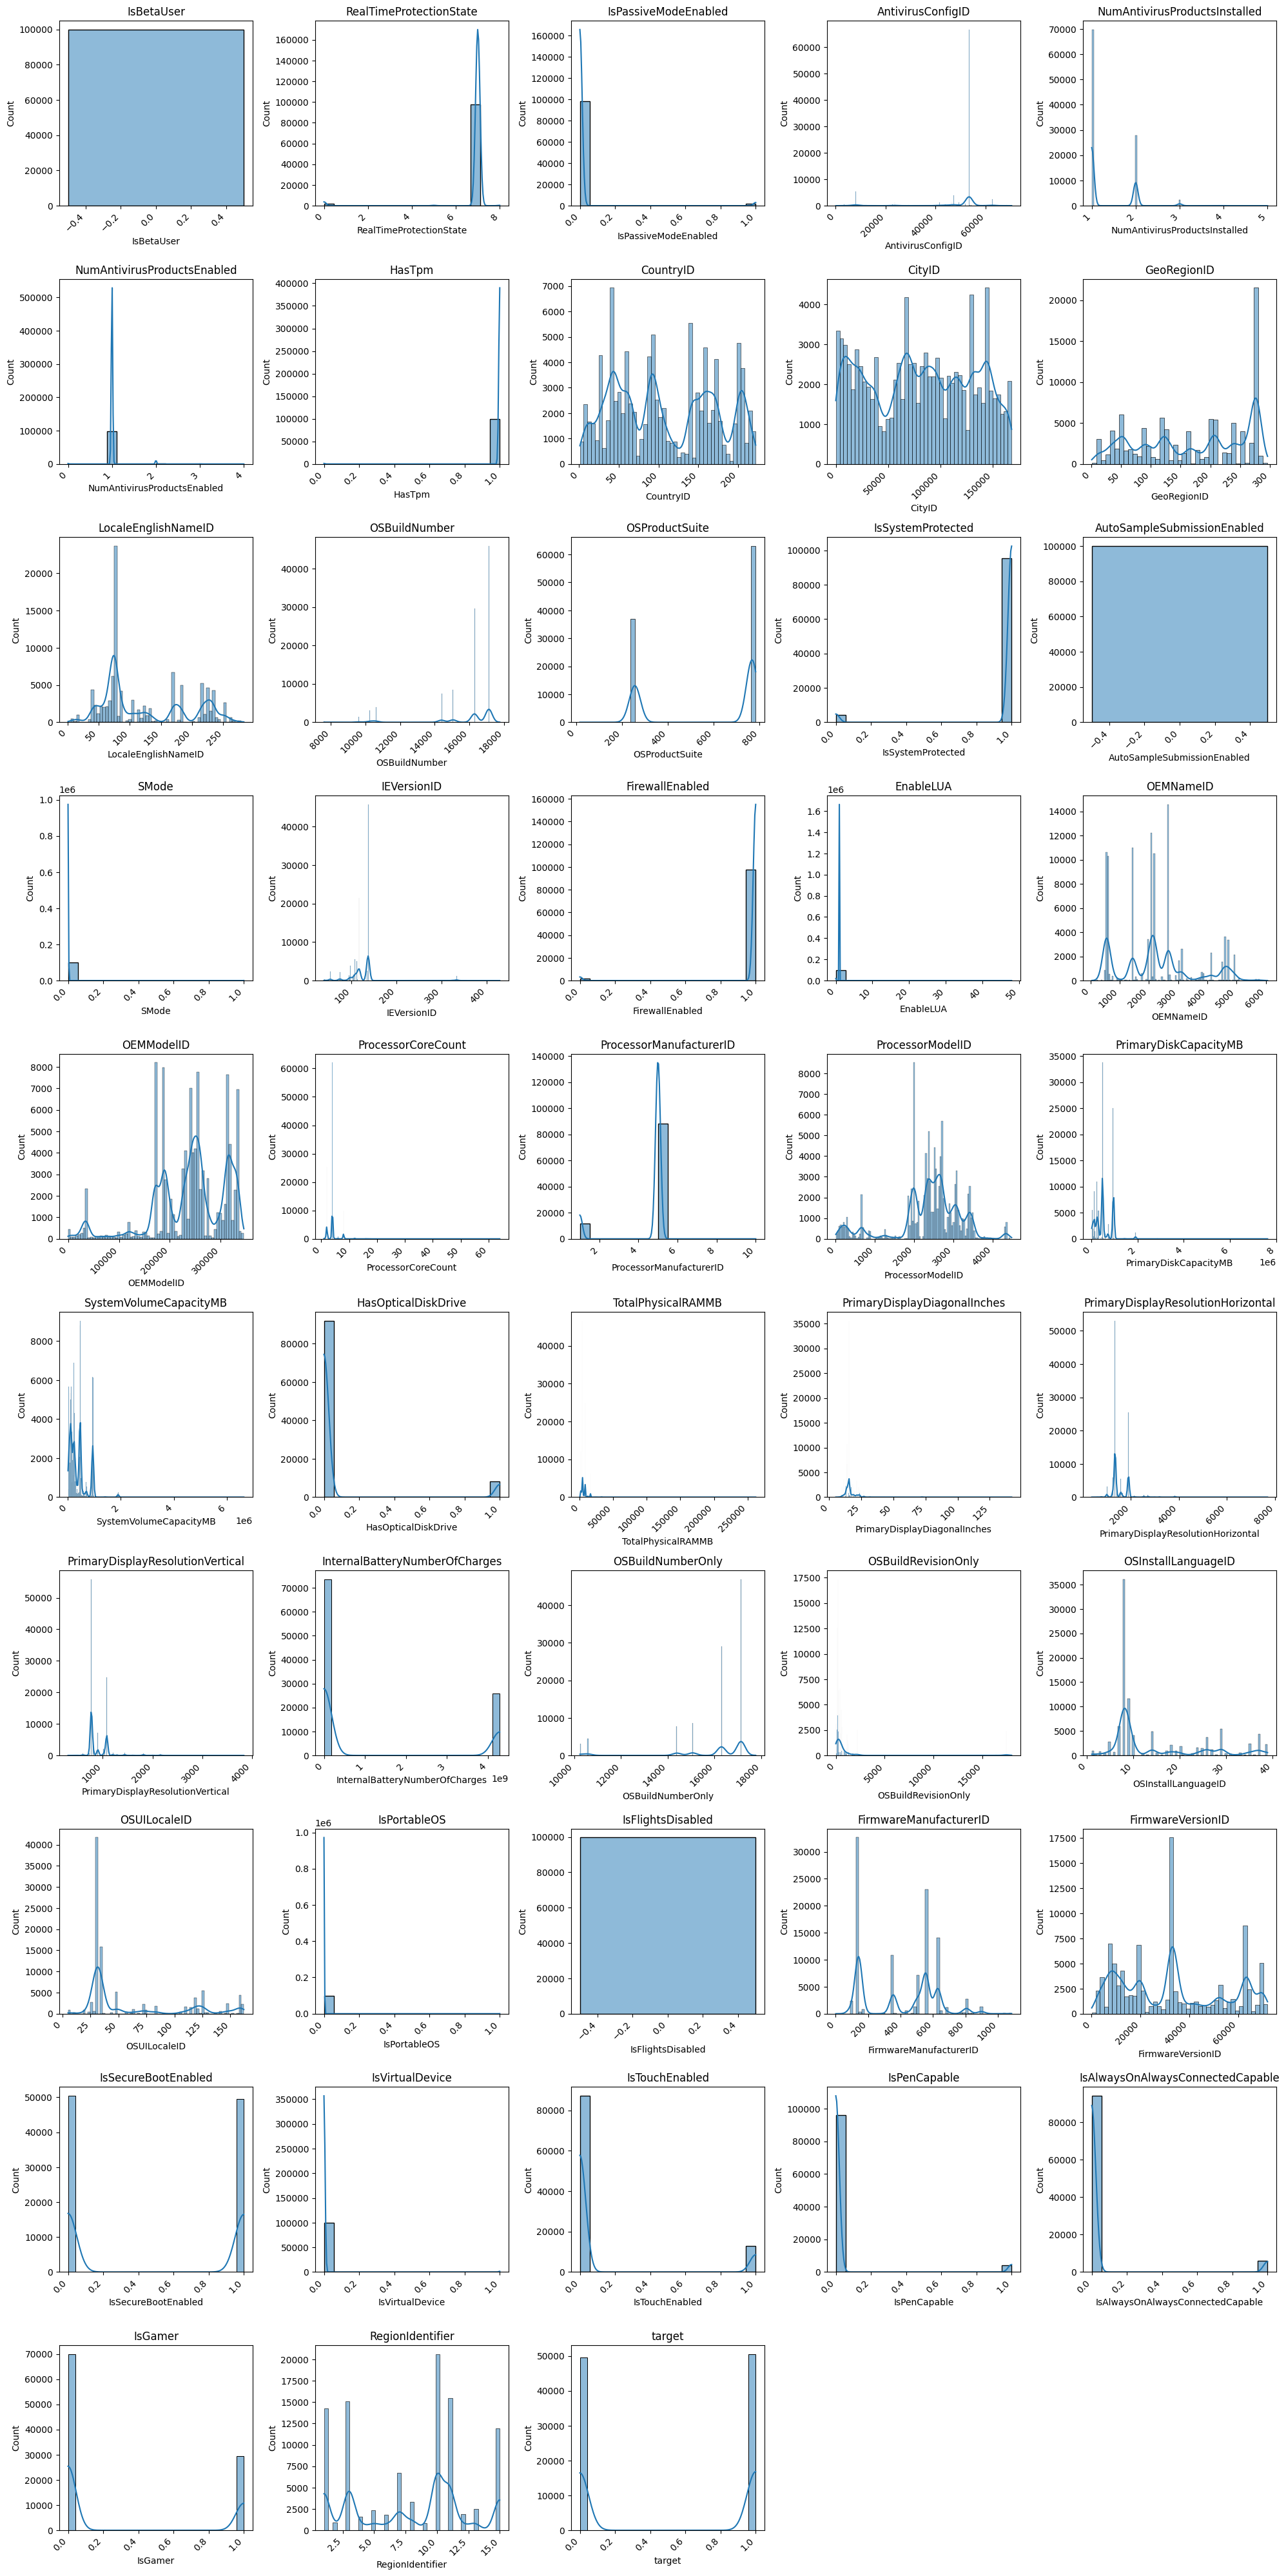

In [12]:
# Histograms for Numerical Features
numerical_features = train_data.select_dtypes(include=['number']).columns
num_numerical = len(numerical_features)
rows = (num_numerical + 4) // 5  # Calculate rows for subplots
plt.figure(figsize=(20, rows * 4))
for i, col in enumerate(numerical_features):
    plt.subplot(rows, 5, i + 1)
    sns.histplot(train_data[col], kde=True)
    plt.title(col)
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

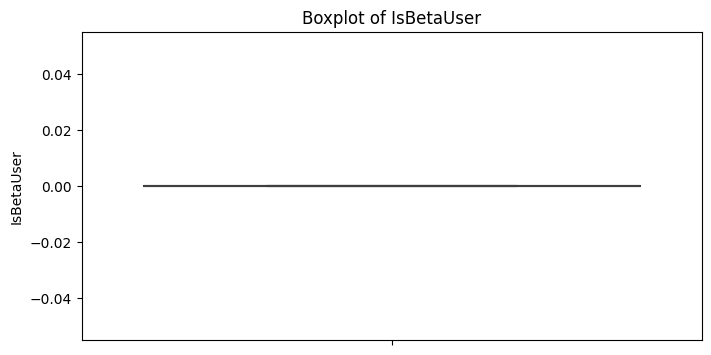

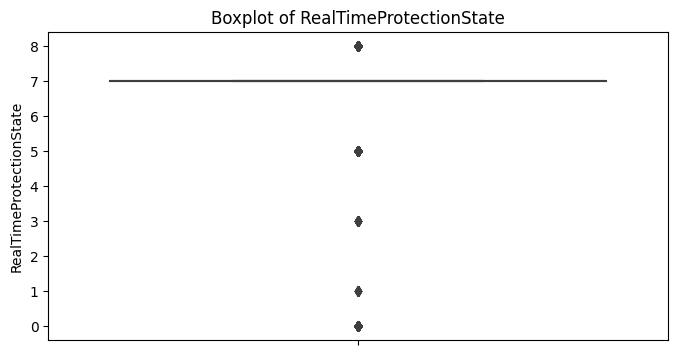

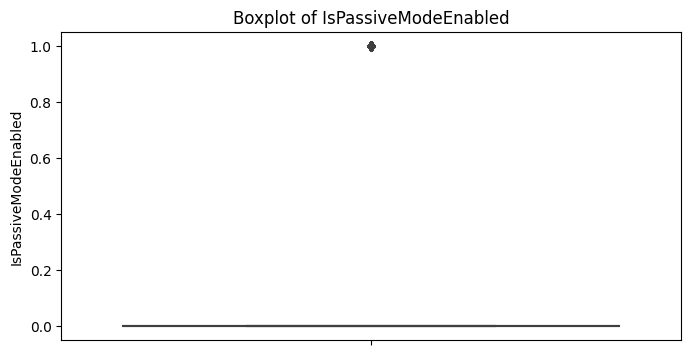

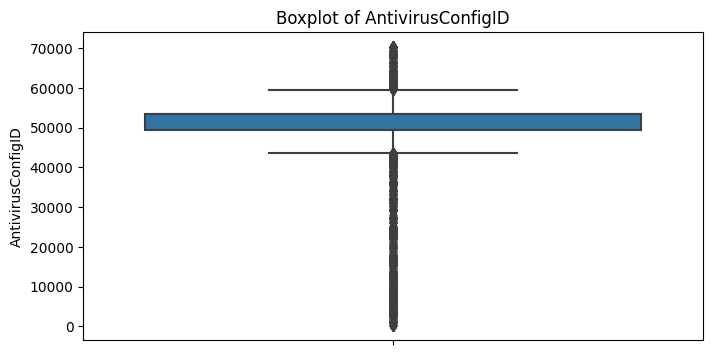

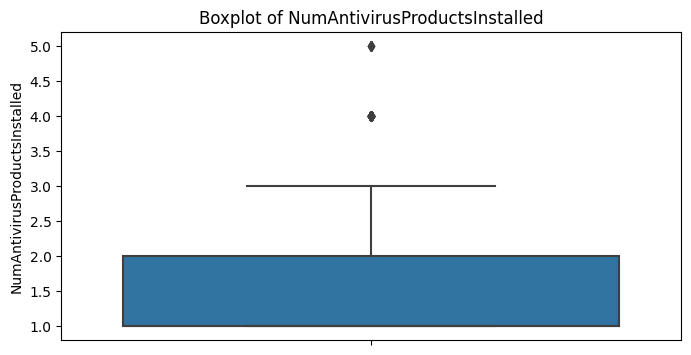

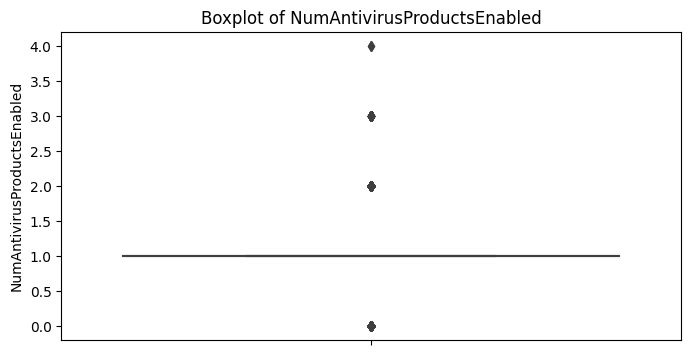

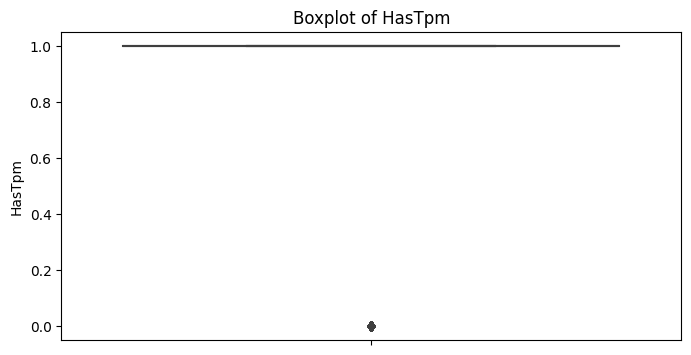

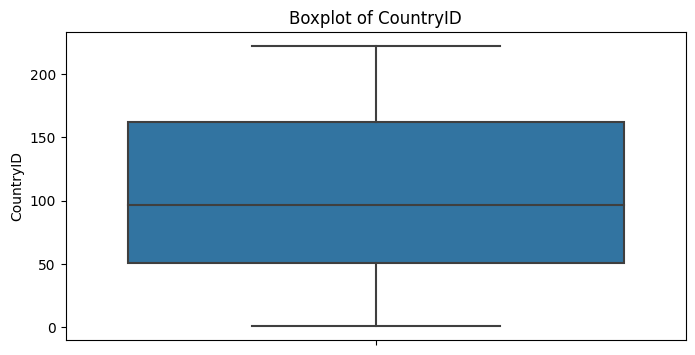

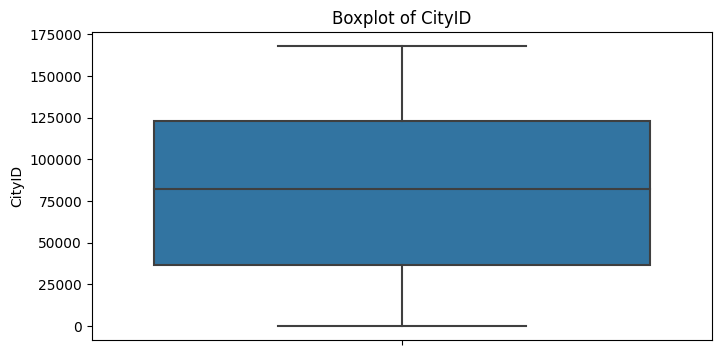

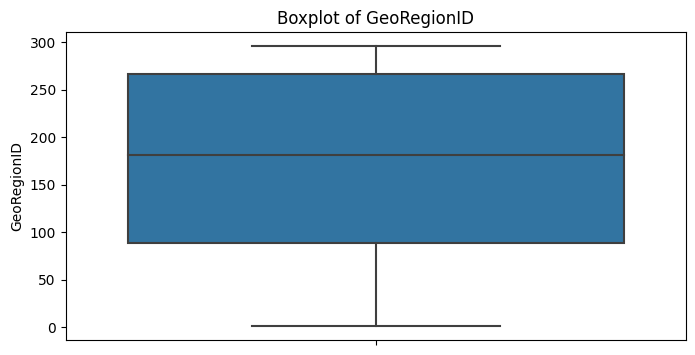

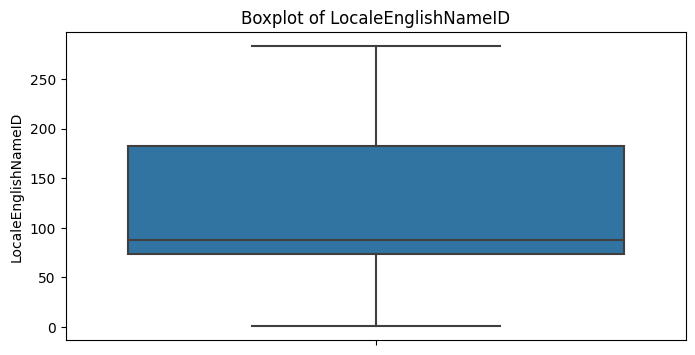

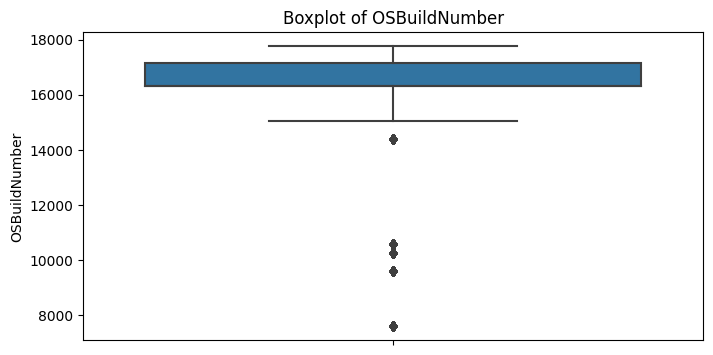

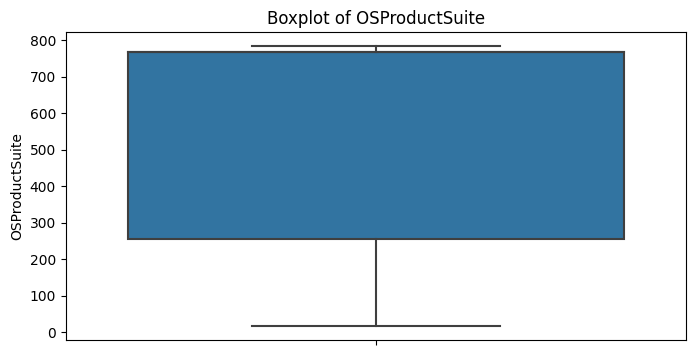

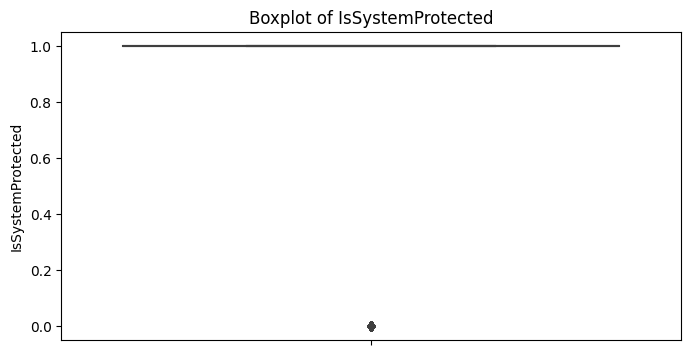

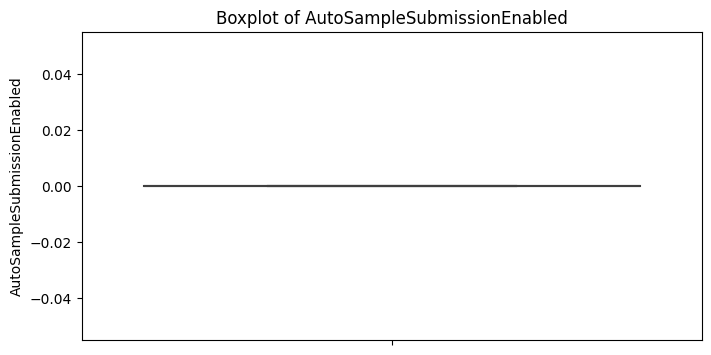

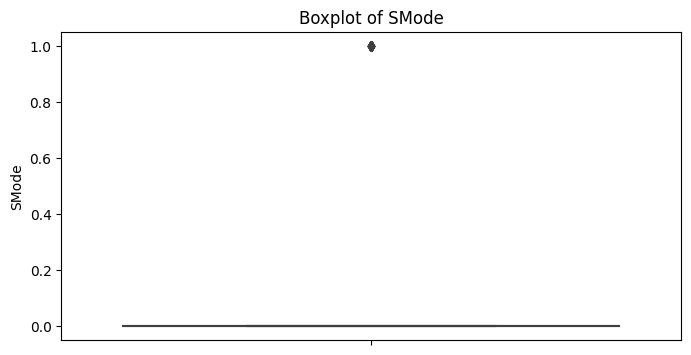

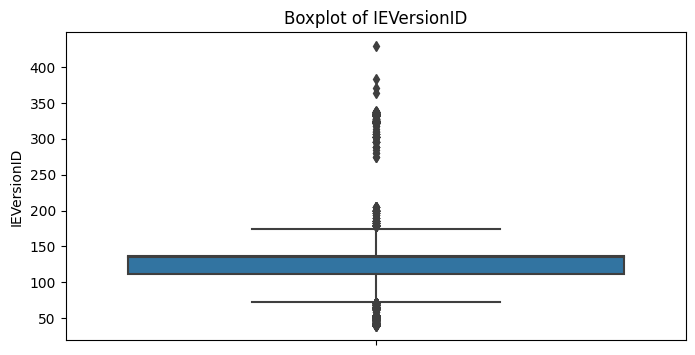

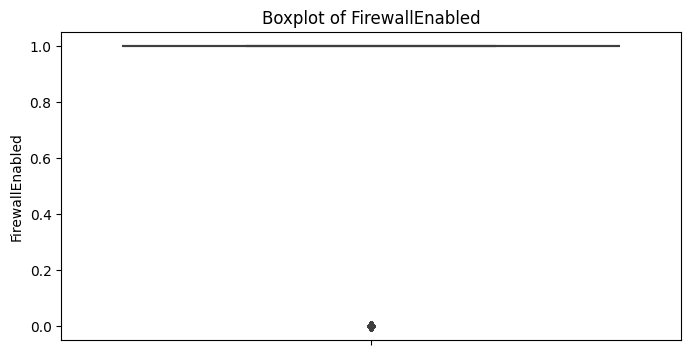

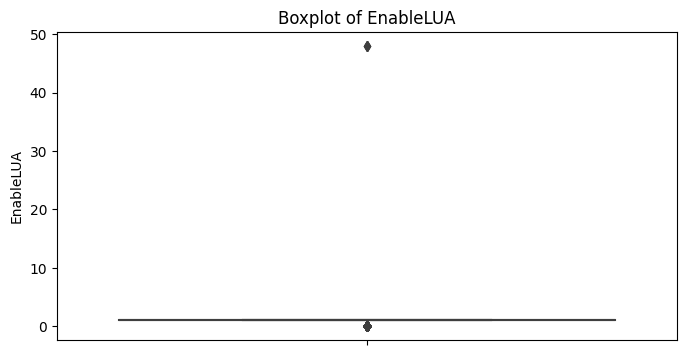

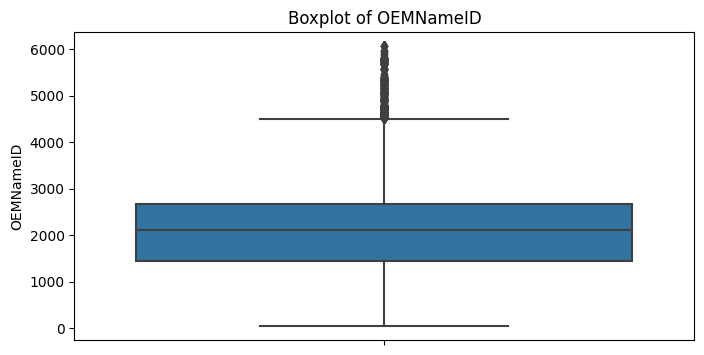

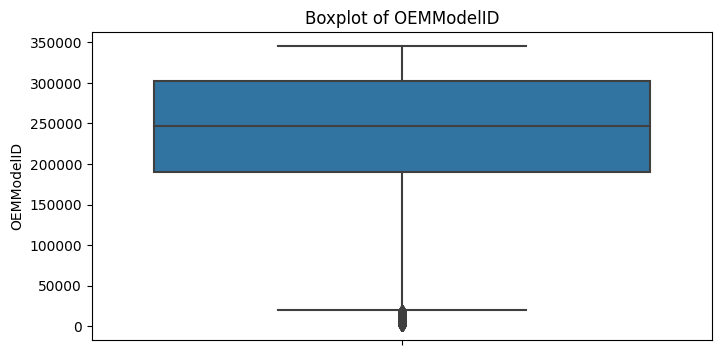

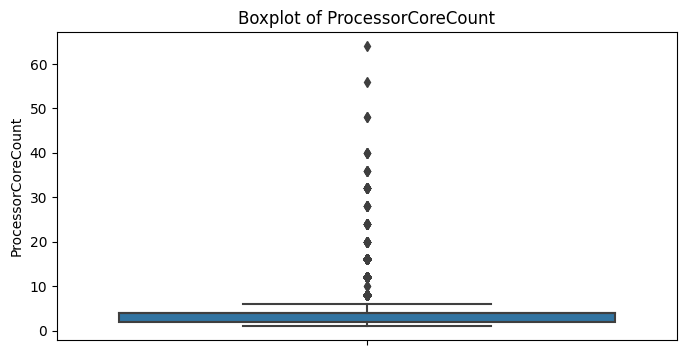

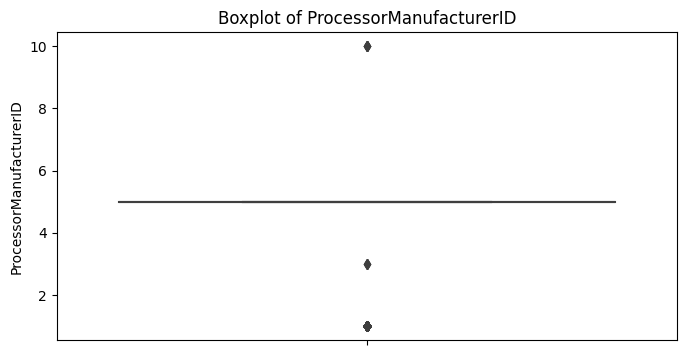

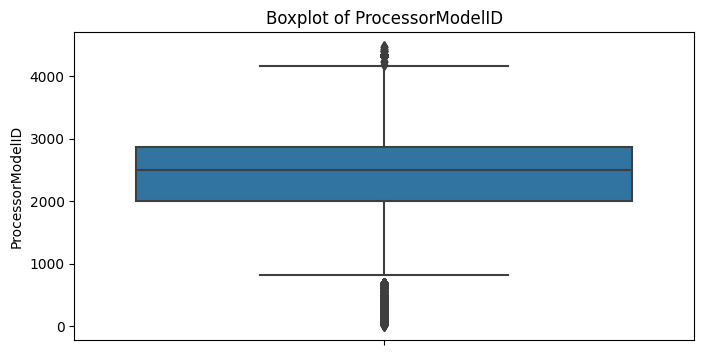

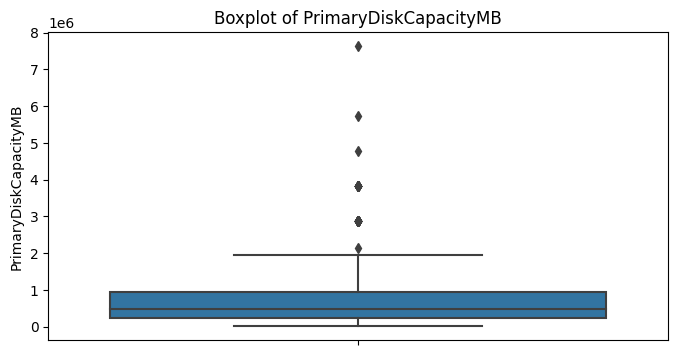

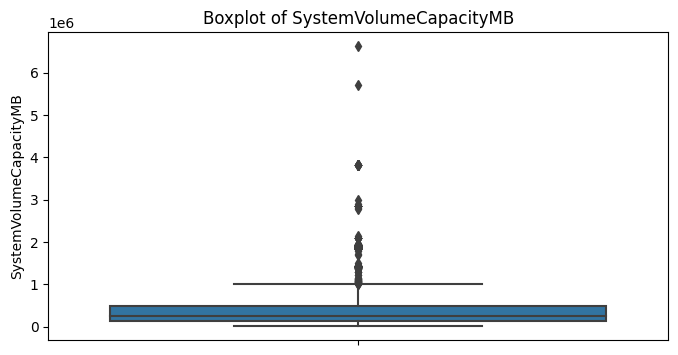

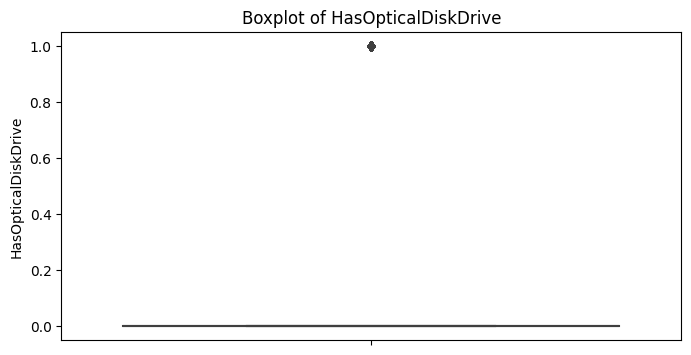

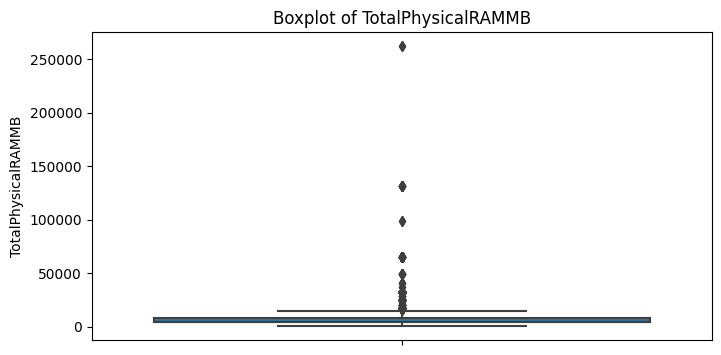

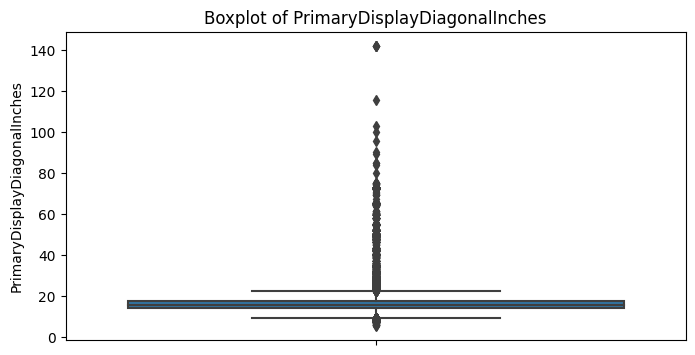

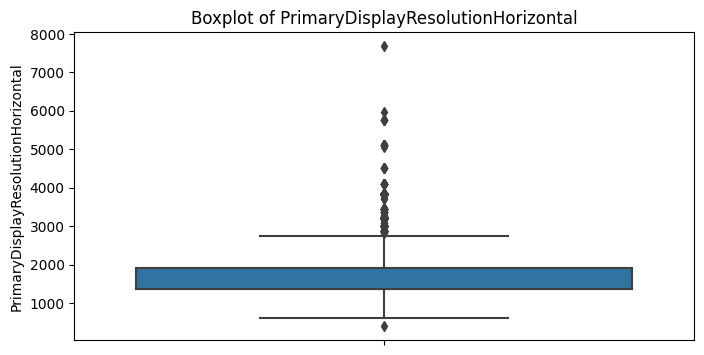

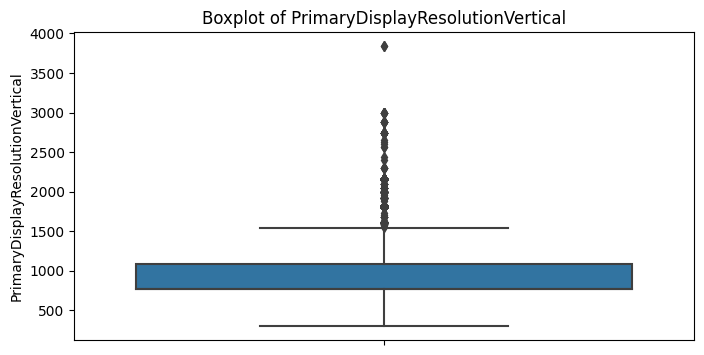

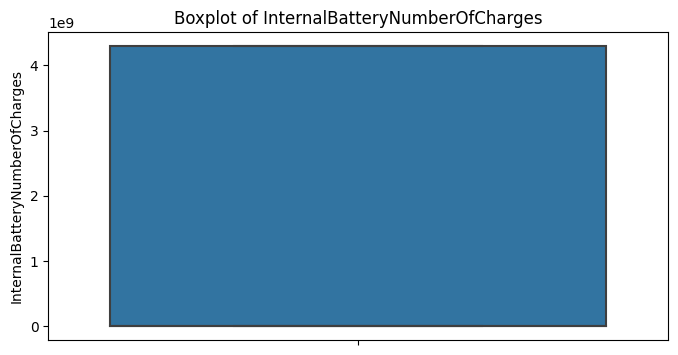

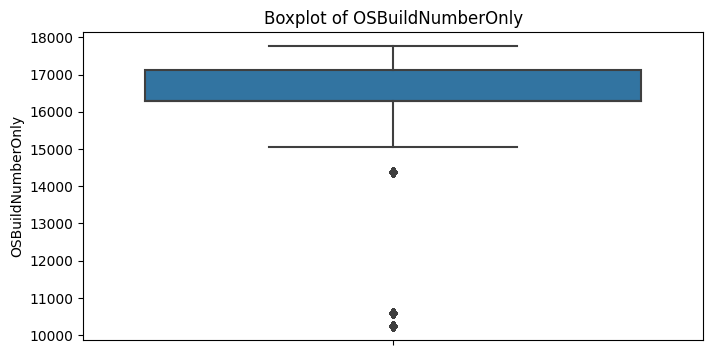

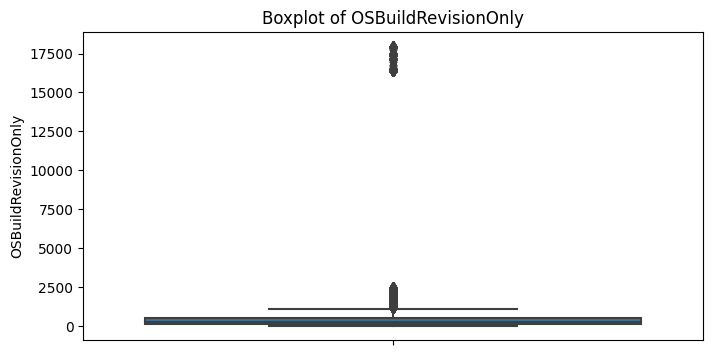

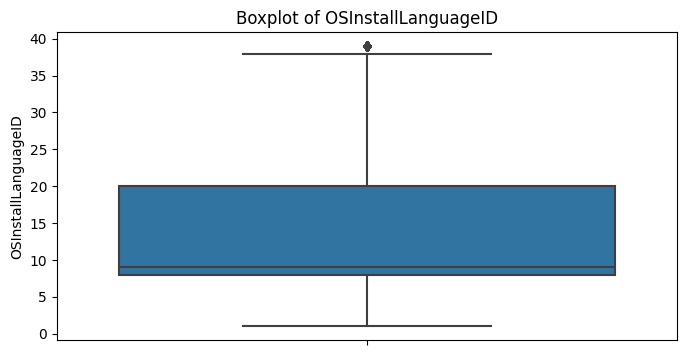

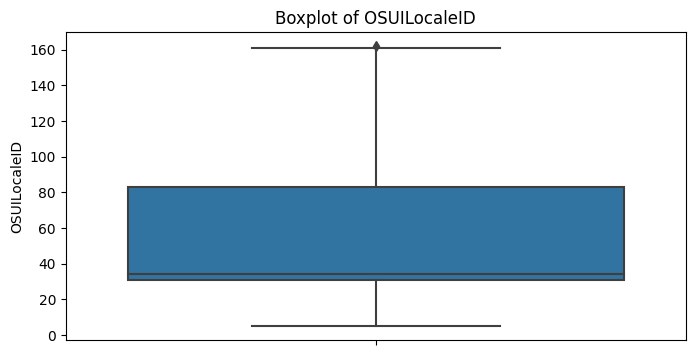

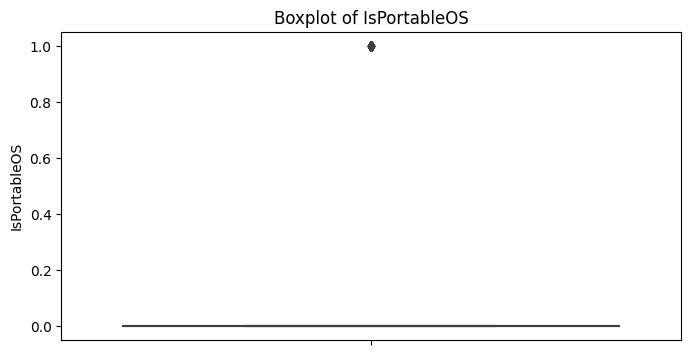

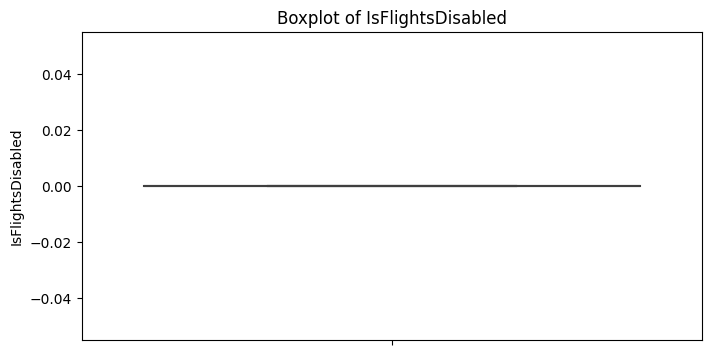

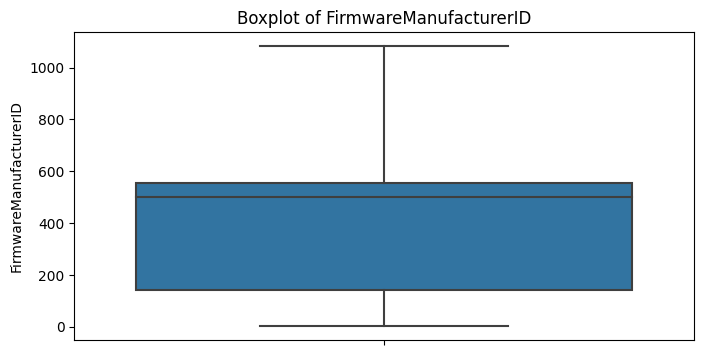

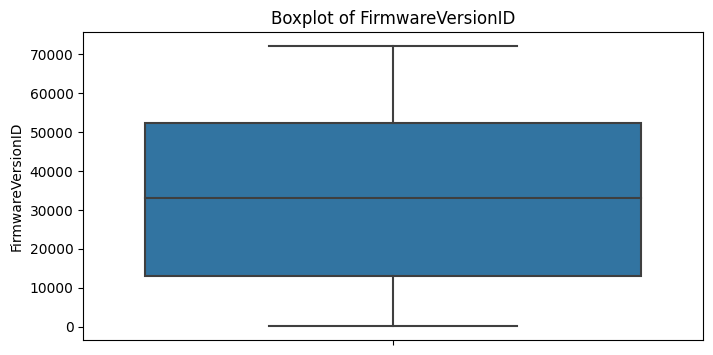

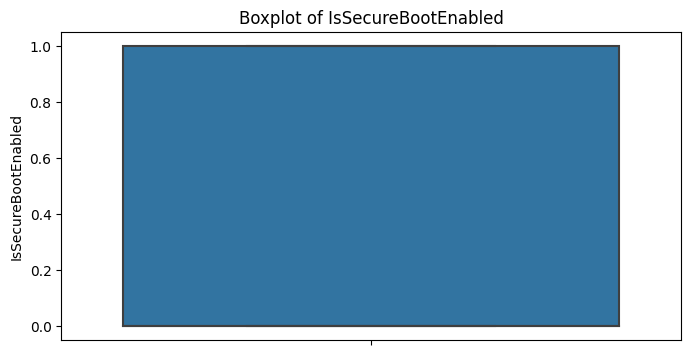

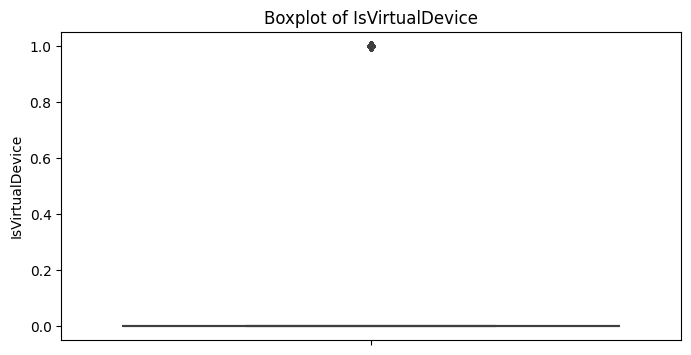

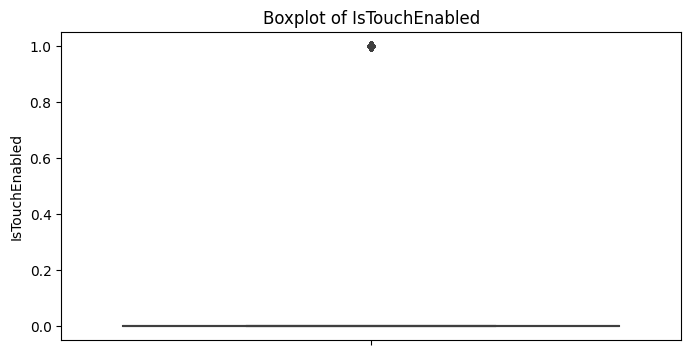

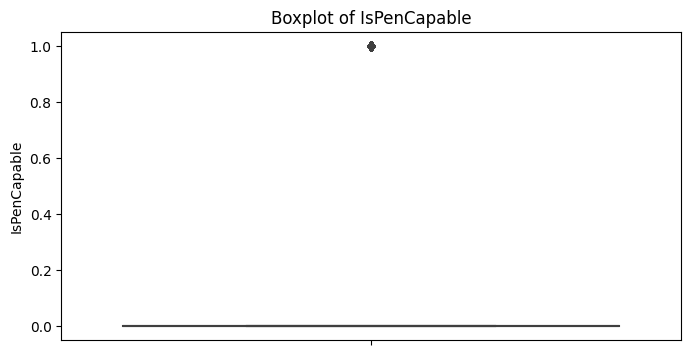

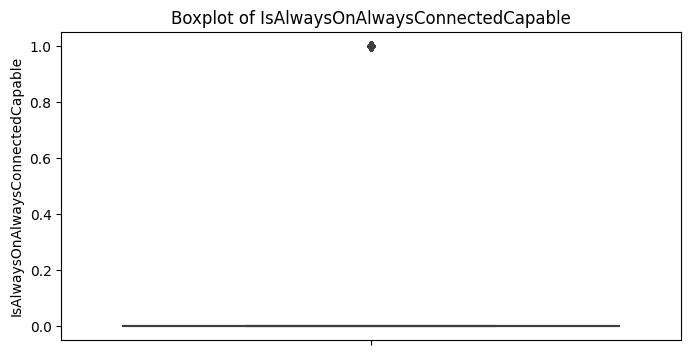

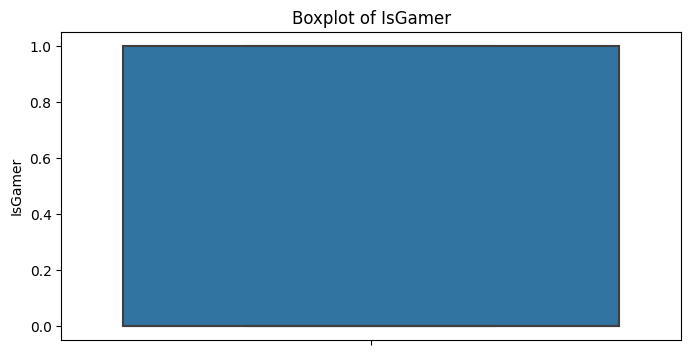

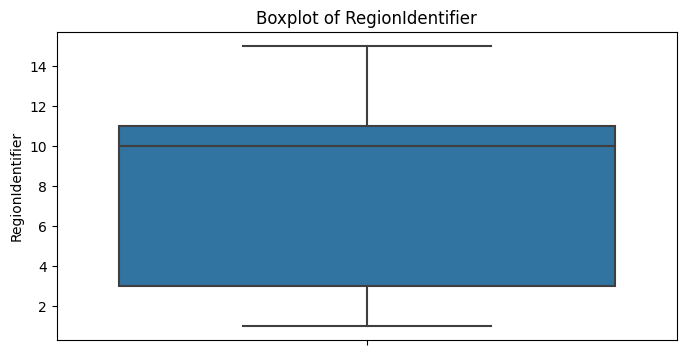

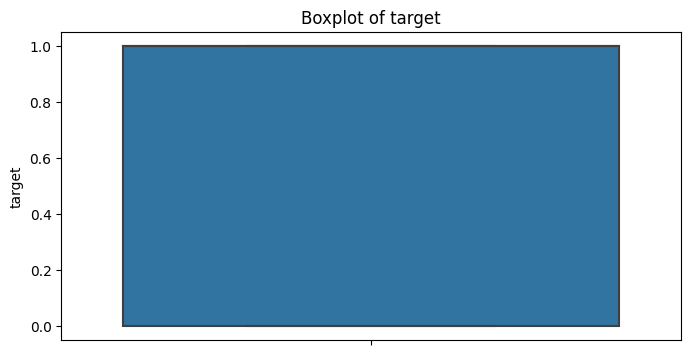

In [13]:
# Box plots for numerical features
for col in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=train_data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

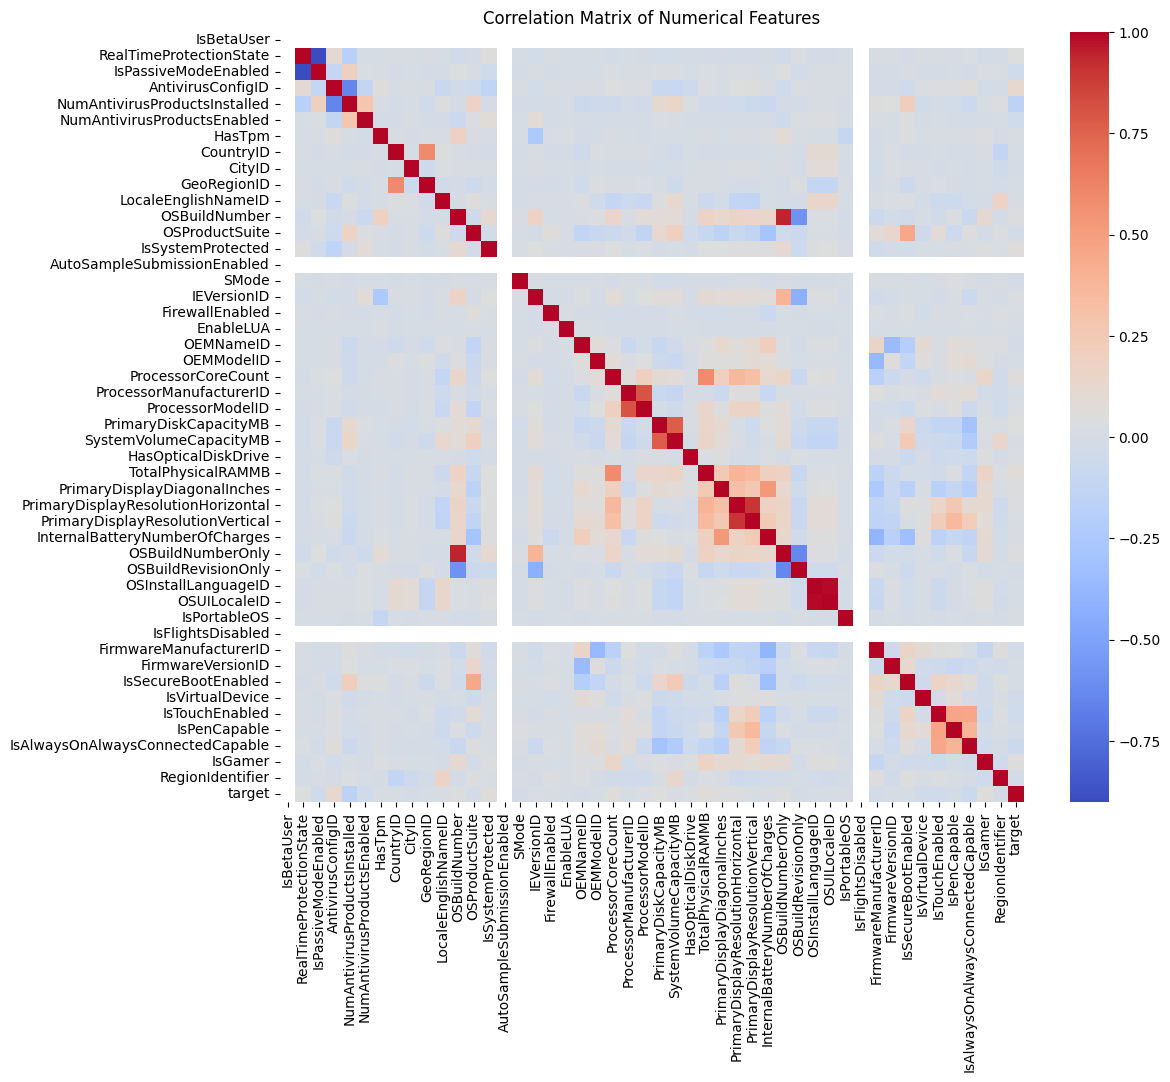

In [14]:
# Correlation matrix heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(train_data[numerical_features].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [15]:
correlation_matrix = train_data.select_dtypes(include=['number']).corr()

# Get correlations of all features with the target column
correlations = correlation_matrix['target'].drop('target')

# Find most positively and negatively correlated features
most_positive_feature = correlations.idxmax()
most_negative_feature = correlations.idxmin()

print(f"📈 Most Positively Correlated Feature: {most_positive_feature} (Correlation: {correlations.max():.4f})")
print(f"📉 Most Negatively Correlated Feature: {most_negative_feature} (Correlation: {correlations.min():.4f})")


📈 Most Positively Correlated Feature: AntivirusConfigID (Correlation: 0.1183)
📉 Most Negatively Correlated Feature: NumAntivirusProductsInstalled (Correlation: -0.1514)


## Categorical Features

Distribution of  Categorical variable:


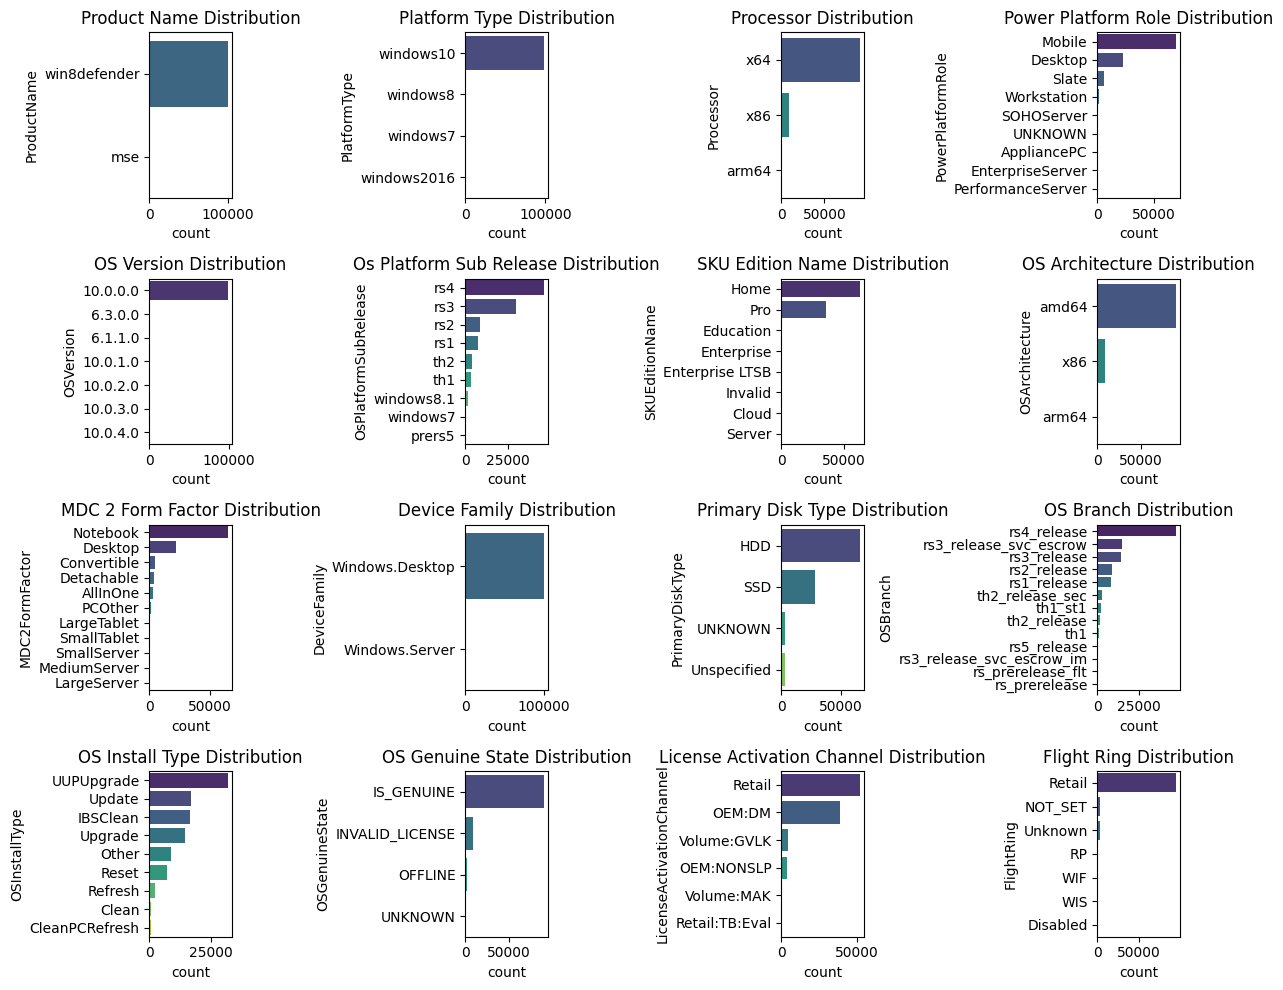

In [16]:
print("\033[1mDistribution of  Categorical variable:\033[1m")
# Visualizing key categorical variables
fig, axes = plt.subplots(4, 4, figsize=(12, 10))
sns.countplot(y=train_data['ProductName'], order=train_data['ProductName'].value_counts().index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title("Product Name Distribution")

sns.countplot(y=train_data['PlatformType'], order=train_data['PlatformType'].value_counts().index, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title("Platform Type Distribution")

sns.countplot(y=train_data['Processor'], order=train_data['Processor'].value_counts().index, ax=axes[0, 2], palette='viridis')
axes[0, 2].set_title("Processor Distribution")

sns.countplot(y=train_data['PowerPlatformRole'], order=train_data['PowerPlatformRole'].value_counts().index, ax=axes[0, 3], palette='viridis')
axes[0, 3].set_title("Power Platform Role Distribution")

sns.countplot(y=train_data['OSVersion'], order=train_data['OSVersion'].value_counts().index, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title("OS Version Distribution")

sns.countplot(y=train_data['OsPlatformSubRelease'], order=train_data['OsPlatformSubRelease'].value_counts().index, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title("Os Platform Sub Release Distribution")

sns.countplot(y=train_data['SKUEditionName'], order=train_data['SKUEditionName'].value_counts().index, ax=axes[1, 2], palette='viridis')
axes[1, 2].set_title("SKU Edition Name Distribution")

sns.countplot(y=train_data['OSArchitecture'], order=train_data['OSArchitecture'].value_counts().index, ax=axes[1, 3], palette='viridis')
axes[1, 3].set_title("OS Architecture Distribution")

sns.countplot(y=train_data['MDC2FormFactor'], order=train_data['MDC2FormFactor'].value_counts().index, ax=axes[2, 0], palette='viridis')
axes[2, 0].set_title("MDC 2 Form Factor Distribution")

sns.countplot(y=train_data['DeviceFamily'], order=train_data['DeviceFamily'].value_counts().index, ax=axes[2, 1], palette='viridis')
axes[2, 1].set_title("Device Family Distribution")

sns.countplot(y=train_data['PrimaryDiskType'], order=train_data['PrimaryDiskType'].value_counts().index, ax=axes[2, 2], palette='viridis')
axes[2, 2].set_title("Primary Disk Type Distribution")

sns.countplot(y=train_data['OSBranch'], order=train_data['OSBranch'].value_counts().index, ax=axes[2, 3], palette='viridis')
axes[2, 3].set_title("OS Branch Distribution")

sns.countplot(y=train_data['OSInstallType'], order=train_data['OSInstallType'].value_counts().index, ax=axes[3, 0], palette='viridis')
axes[3, 0].set_title("OS Install Type Distribution")

sns.countplot(y=train_data['OSGenuineState'], order=train_data['OSGenuineState'].value_counts().index, ax=axes[3, 1], palette='viridis')
axes[3, 1].set_title("OS Genuine State Distribution")

sns.countplot(y=train_data['LicenseActivationChannel'], order=train_data['LicenseActivationChannel'].value_counts().index, ax=axes[3, 2], palette='viridis')
axes[3, 2].set_title("License Activation Channel Distribution")

sns.countplot(y=train_data['FlightRing'], order=train_data['FlightRing'].value_counts().index, ax=axes[3, 3], palette='viridis')
axes[3, 3].set_title("Flight Ring Distribution")

plt.tight_layout()
plt.show()

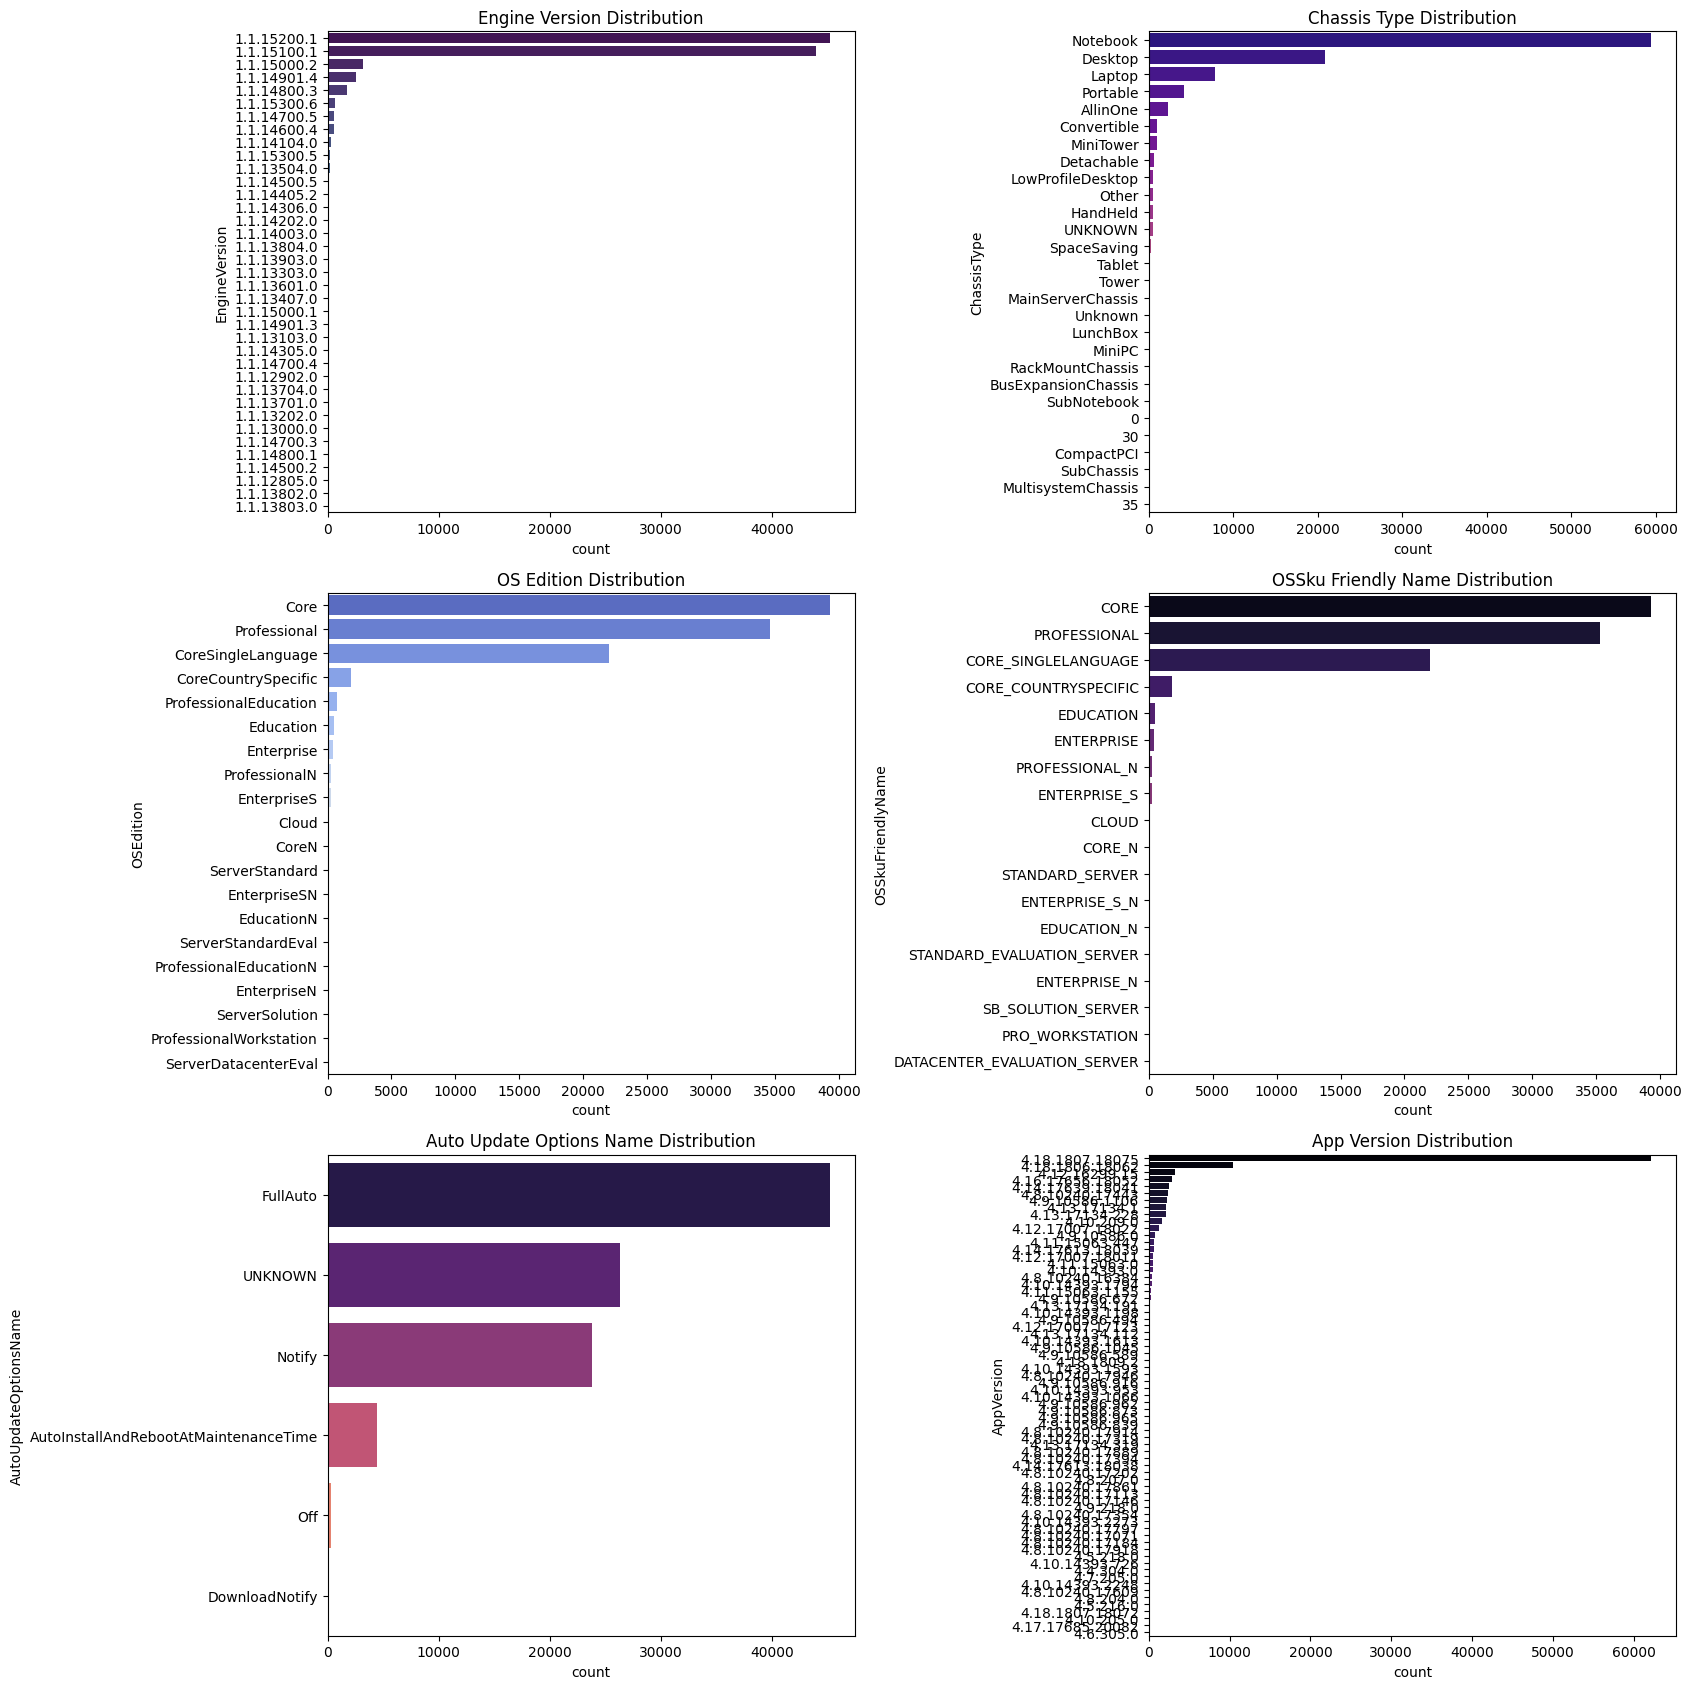

In [17]:
# Visualizing key categorical variables
fig, axes = plt.subplots(3, 2, figsize=(17, 17))

sns.countplot(y=train_data['EngineVersion'], order=train_data['EngineVersion'].value_counts().index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title("Engine Version Distribution")

sns.countplot(y=train_data['ChassisType'], order=train_data['ChassisType'].value_counts().index, ax=axes[0, 1], palette='plasma')
axes[0, 1].set_title("Chassis Type Distribution")

sns.countplot(y=train_data['OSEdition'], order=train_data['OSEdition'].value_counts().index, ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title("OS Edition Distribution")

sns.countplot(y=train_data['OSSkuFriendlyName'], order=train_data['OSSkuFriendlyName'].value_counts().index, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title("OSSku Friendly Name Distribution")

sns.countplot(y=train_data['AutoUpdateOptionsName'], order=train_data['AutoUpdateOptionsName'].value_counts().index, ax=axes[2, 0], palette='magma')
axes[2, 0].set_title("Auto Update Options Name Distribution")

sns.countplot(y=train_data['AppVersion'], order=train_data['AppVersion'].value_counts().index, ax=axes[2, 1], palette='magma')
axes[2, 1].set_title("App Version Distribution")

plt.tight_layout()
plt.show()


# Data Cleaning

In [18]:
# Remove duplicate rows from the training dataset to ensure each entry is unique
# This helps prevent model bias and improves the quality of the training data
train_data.drop_duplicates(inplace=True)

In [19]:
# Drop irrelevant or redundant columns to reduce noise and prevent overfitting
train_data_cleaned = train_data.drop(columns=[
    'IsBetaUser', 'AutoSampleSubmissionEnabled', 'IsFlightsDisabled', 
    'GeoRegionID', 'ChassisType', 'MachineID', 'ProcessorManufacturerID', 
    'ProcessorModelID', 'EnableLUA'
])

1. These columns provide no useful information because they have **constant values** (always 0):

* IsBetaUser
* AutoSampleSubmissionEnabled
* IsFlightsDisabled
2. When features are highly correlated (multicollinearity), they can **confuse models** and increase training time.
    * GeoRegionID **(keep CountryID)**
    * ChassisType **(keep InternalBatteryNumberOfCharges)**
    


In [20]:
# Separate features and target
X = train_data_cleaned.drop(columns=['target'])
y = train_data_cleaned['target']

# X = train_data.drop(columns=['target'])
# y = train_data['target']

In [21]:
# Getting numerical feature names as a list
numerical_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Getting categorical feature names as a list
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Data Preprocessing 

In [22]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # Handle missing values
    ('scaler', StandardScaler())  # Scale numerical features
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore')), # One-hot encode
])

In [23]:
preprocessor = ColumnTransformer([
    ('categorical_processing', categorical_pipeline, categorical_features),
    ('numerical_processing', numerical_pipeline, numerical_features)
], remainder='drop')

preprocessor

ColumnTransformer(transformers=[('categorical_processing',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['ProductName', 'EngineVersion', 'AppVersion',
                                  'SignatureVersion', 'PlatformType',
                                  'Processor', 'OSVersion',
                                  'OsPlatformSubRelease', 'OSBuildLab',
                                  'SKUEditionName', 'MDC2FormFactor',...
                                  'FirewallEnabled', 'OEMNameID', 'OEMModelID',
                                  'ProcessorCoreCount', 'PrimaryDiskCapacityMB',
                                  'SystemVolumeCapacityMB',
                                  'HasOpticalDiskDrive', 'TotalPhysicalRAMMB',
                                  'PrimaryDisplayDiagonalInches',
                                  'PrimaryDisplayResolutionHorizontal',
                                  'PrimaryDisplayResolutionVertical',
                                  'InternalBatteryNumberOfCharges',
                                  'OSBuildNumberOnly', 'OSBuildRevisionOnly',
                                  'OSInstallLanguageID', 'OSUILocaleID', ...])])

In [24]:
# Split into train and test sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"Training Data Shape: {X_train.shape}")
print(f"Validation Data Shape: {X_val.shape}")


Training Data Shape: (79868, 66)
Validation Data Shape: (19967, 66)


## Feature Scaling

In [25]:
numerical_Pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # Handle missing values
    ('scaler', StandardScaler()),  # Scale numerical features
    ('pca' , PCA(n_components=25))#
])

categorical_Pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore')), # One-hot encode
    ('select_best', SelectKBest(chi2, k=15))
])

In [26]:
Preprocessor = ColumnTransformer([
    ('categorical_processing', categorical_Pipeline, categorical_features),
    ('numerical_processing', numerical_Pipeline, numerical_features)
], remainder='drop')

Preprocessor

ColumnTransformer(transformers=[('categorical_processing',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore')),
                                                 ('select_best',
                                                  SelectKBest(k=15,
                                                              score_func=<function chi2 at 0x78932a548430>))]),
                                 ['ProductName', 'EngineVersion', 'AppVersion',
                                  'SignatureVersion', 'PlatformType',
                                  'Processor', 'OSVer...
                                  'FirewallEnabled', 'OEMNameID', 'OEMModelID',
                                  'ProcessorCoreCount', 'PrimaryDiskCapacityMB',
                                  'SystemVolumeCapacityMB',
                                  'HasOpticalDiskDrive', 'TotalPhysicalRAMMB',
                                  'PrimaryDisplayDiagonalInches',
                                  'PrimaryDisplayResolutionHorizontal',
                                  'PrimaryDisplayResolutionVertical',
                                  'InternalBatteryNumberOfCharges',
                                  'OSBuildNumberOnly', 'OSBuildRevisionOnly',
                                  'OSInstallLanguageID', 'OSUILocaleID', ...])])

# Model Building

## LogisticRegression

In [27]:
# Define the pipeline
logistic_model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("logistic", LogisticRegression(random_state = 0, max_iter=600))
])

# Train the model
logistic_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical_processing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ProductName',
                                                   'EngineVersion',
                                                   'AppVersion',
                                                   'SignatureVersion',
                                                   'PlatformType', 'Processor',
                                                   'OSVersion',
                                                   'OsPlatformSubRelease',
                                                   'OSBuildLab',
                                                   'S...
                                                   'SystemVolumeCapacityMB',
                                                   'HasOpticalDiskDrive',
                                                   'TotalPhysicalRAMMB',
                                                   'PrimaryDisplayDiagonalInches',
                                                   'PrimaryDisplayResolutionHorizontal',
                                                   'PrimaryDisplayResolutionVertical',
                                                   'InternalBatteryNumberOfCharges',
                                                   'OSBuildNumberOnly',
                                                   'OSBuildRevisionOnly',
                                                   'OSInstallLanguageID',
                                                   'OSUILocaleID', ...])])),
                ('logistic', LogisticRegression(max_iter=600, random_state=0))])

In [28]:
logistic_accuracy=logistic_model_pipeline.score(X_val, y_val)
print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")

Logistic Regression Accuracy: 0.6094


### LogisticRegression with feature scaling pipeline

In [29]:
# Define the pipeline
Logistic_model_pipeline = Pipeline(steps=[
    ("Preprocessor", Preprocessor),
    ("logistic", LogisticRegression(random_state = 0, max_iter=600))
])

# Train the model
Logistic_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('categorical_processing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore')),
                                                                  ('select_best',
                                                                   SelectKBest(k=15,
                                                                               score_func=<function chi2 at 0x78932a548430>))]),
                                                  ['ProductName',
                                                   'EngineVersion',
                                                   'AppVersion',
                                                   'SignatureVersion',
                                                   '...
                                                   'SystemVolumeCapacityMB',
                                                   'HasOpticalDiskDrive',
                                                   'TotalPhysicalRAMMB',
                                                   'PrimaryDisplayDiagonalInches',
                                                   'PrimaryDisplayResolutionHorizontal',
                                                   'PrimaryDisplayResolutionVertical',
                                                   'InternalBatteryNumberOfCharges',
                                                   'OSBuildNumberOnly',
                                                   'OSBuildRevisionOnly',
                                                   'OSInstallLanguageID',
                                                   'OSUILocaleID', ...])])),
                ('logistic', LogisticRegression(max_iter=600, random_state=0))])

In [30]:
Logistic_accuracy=Logistic_model_pipeline.score(X_val, y_val)
print(f"Logistic Regression Accuracy after feature scaling: {Logistic_accuracy:.4f}")

Logistic Regression Accuracy after feature scaling: 0.6113


**Observation**
* Feature scaling led to a subtle yet meaningful improvement in the *Logistic Regression model's* accuracy, rising from *0.6094* to *0.6115*. This demonstrates how scaling helps standardize feature contributions, refining the model’s performance and stability. 🚀📊

## SGDClassifier

In [31]:
# Define the pipeline
sgd_model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ('sgd_classifier', SGDClassifier(random_state=0))
])

# Train the model
sgd_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical_processing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ProductName',
                                                   'EngineVersion',
                                                   'AppVersion',
                                                   'SignatureVersion',
                                                   'PlatformType', 'Processor',
                                                   'OSVersion',
                                                   'OsPlatformSubRelease',
                                                   'OSBuildLab',
                                                   'S...
                                                   'PrimaryDiskCapacityMB',
                                                   'SystemVolumeCapacityMB',
                                                   'HasOpticalDiskDrive',
                                                   'TotalPhysicalRAMMB',
                                                   'PrimaryDisplayDiagonalInches',
                                                   'PrimaryDisplayResolutionHorizontal',
                                                   'PrimaryDisplayResolutionVertical',
                                                   'InternalBatteryNumberOfCharges',
                                                   'OSBuildNumberOnly',
                                                   'OSBuildRevisionOnly',
                                                   'OSInstallLanguageID',
                                                   'OSUILocaleID', ...])])),
                ('sgd_classifier', SGDClassifier(random_state=0))])

In [32]:
sgd_accuracy = sgd_model_pipeline.score(X_val, y_val)
print(f"SGD Classifier Accuracy: {sgd_accuracy:.4f}")

SGD Classifier Accuracy: 0.6050


### Hyperparameter Tuning 

In [33]:
param_grid = {
    'sgd_classifier__alpha': [0.0001, 0.001, 0.01, 0.1],
    'sgd_classifier__penalty': ['l1', 'l2', 'elasticnet'],
    'sgd_classifier__learning_rate': ['constant', 'optimal', 'adaptive'],
}

grid_search = GridSearchCV(sgd_model_pipeline, param_grid, cv=3, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
best_pipeline

Fitting 3 folds for each of 36 candidates, totalling 108 fits


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical_processing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ProductName',
                                                   'EngineVersion',
                                                   'AppVersion',
                                                   'SignatureVersion',
                                                   'PlatformType', 'Processor',
                                                   'OSVersion',
                                                   'OsPlatformSubRelease',
                                                   'OSBuildLab',
                                                   'S...
                                                   'SystemVolumeCapacityMB',
                                                   'HasOpticalDiskDrive',
                                                   'TotalPhysicalRAMMB',
                                                   'PrimaryDisplayDiagonalInches',
                                                   'PrimaryDisplayResolutionHorizontal',
                                                   'PrimaryDisplayResolutionVertical',
                                                   'InternalBatteryNumberOfCharges',
                                                   'OSBuildNumberOnly',
                                                   'OSBuildRevisionOnly',
                                                   'OSInstallLanguageID',
                                                   'OSUILocaleID', ...])])),
                ('sgd_classifier', SGDClassifier(alpha=0.001, random_state=0))])

In [34]:
SGD_accuracy = best_pipeline.score(X_val, y_val)
print(f"SGD Classifier Accuracy after hyperparameter tuning: {SGD_accuracy:.4f}")

SGD Classifier Accuracy after hyperparameter tuning: 0.6137


**Observation**
* With hyperparameter tuning, the *SGD Classifier* saw a significant improvement, elevating its accuracy from *0.6050* to *0.6137*. This highlights the impact of fine-tuning in unlocking better model performance and precision. 🔥📈

## RandomForestClassifier

In [35]:
# Define the pipeline
random_model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=0))
])

# Train the model
random_model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical_processing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ProductName',
                                                   'EngineVersion',
                                                   'AppVersion',
                                                   'SignatureVersion',
                                                   'PlatformType', 'Processor',
                                                   'OSVersion',
                                                   'OsPlatformSubRelease',
                                                   'OSBuildLab',
                                                   'S...
                                                   'PrimaryDiskCapacityMB',
                                                   'SystemVolumeCapacityMB',
                                                   'HasOpticalDiskDrive',
                                                   'TotalPhysicalRAMMB',
                                                   'PrimaryDisplayDiagonalInches',
                                                   'PrimaryDisplayResolutionHorizontal',
                                                   'PrimaryDisplayResolutionVertical',
                                                   'InternalBatteryNumberOfCharges',
                                                   'OSBuildNumberOnly',
                                                   'OSBuildRevisionOnly',
                                                   'OSInstallLanguageID',
                                                   'OSUILocaleID', ...])])),
                ('classifier', RandomForestClassifier(random_state=0))])

In [36]:
rf_accuracy=random_model_pipeline.score(X_val, y_val)
print(f"Random Forest Accuracy: {rf_accuracy}")

Random Forest Accuracy: 0.6191215505584214


## XGBClassifier

In [37]:
# Define the pipeline
xgb_model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(random_state=0))
])

# Train the model
xgb_model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical_processing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ProductName',
                                                   'EngineVersion',
                                                   'AppVersion',
                                                   'SignatureVersion',
                                                   'PlatformType', 'Processor',
                                                   'OSVersion',
                                                   'OsPlatformSubRelease',
                                                   'OSBuildLab',
                                                   'S...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=0, ...))])

In [38]:
xgb_accuracy=xgb_model_pipeline.score(X_val, y_val)
print(f"XGBoost Accuracy: {xgb_accuracy}")

XGBoost Accuracy: 0.6231782441027696


### XGBClassifier with feature scaling pipeline

In [39]:
# Define the pipeline
XGB_model_pipeline = Pipeline(steps=[
    ("Preprocessor", Preprocessor),
    ("classifier", XGBClassifier(random_state=0))
])

# Train the model
XGB_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('categorical_processing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore')),
                                                                  ('select_best',
                                                                   SelectKBest(k=15,
                                                                               score_func=<function chi2 at 0x78932a548430>))]),
                                                  ['ProductName',
                                                   'EngineVersion',
                                                   'AppVersion',
                                                   'SignatureVersion',
                                                   '...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=0, ...))])

In [40]:
XGB_accuracy=XGB_model_pipeline.score(X_val, y_val)
print(f"XGBoost Accuracy after feature scaling: {XGB_accuracy}")

XGBoost Accuracy after feature scaling: 0.5994390744728803


📊 **Observation on XGBoost Model Performance**
* Before Feature Scaling: ✅ Accuracy = 62.32%
* After Feature Scaling: ❌ Accuracy = 60.01%

🔍 **Key Insight:**
* Feature scaling resulted in a *2.11% drop in accuracy*, indicating that *XGBoost does not benefit from scaling* since it is a *tree-based model*. Unlike linear models, XGBoost makes decisions based on *feature splits*, not numerical magnitudes, making scaling unnecessary.

## LGBMClassifier 

In [41]:
# Define the pipeline
lgbm_model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=30, random_state=0, n_jobs=-1))
])

# Train the model
lgbm_model_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 40360, number of negative: 39508
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.452757 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7541
[LightGBM] [Info] Number of data points in the train set: 79868, number of used features: 2231
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505334 -> initscore=0.021336
[LightGBM] [Info] Start training from score 0.021336


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical_processing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ProductName',
                                                   'EngineVersion',
                                                   'AppVersion',
                                                   'SignatureVersion',
                                                   'PlatformType', 'Processor',
                                                   'OSVersion',
                                                   'OsPlatformSubRelease',
                                                   'OSBuildLab',
                                                   'S...
                                                   'TotalPhysicalRAMMB',
                                                   'PrimaryDisplayDiagonalInches',
                                                   'PrimaryDisplayResolutionHorizontal',
                                                   'PrimaryDisplayResolutionVertical',
                                                   'InternalBatteryNumberOfCharges',
                                                   'OSBuildNumberOnly',
                                                   'OSBuildRevisionOnly',
                                                   'OSInstallLanguageID',
                                                   'OSUILocaleID', ...])])),
                ('classifier',
                 LGBMClassifier(learning_rate=0.05, max_depth=30,
                                n_estimators=400, n_jobs=-1, random_state=0))])

In [42]:
lgbm_accuracy=lgbm_model_pipeline.score(X_val, y_val)
print(f"LightGBM Accuracy: {lgbm_accuracy}")

LightGBM Accuracy: 0.6325937797365654


In [43]:
# y_pred=lgbm_model_pipeline.predict(test_data)

# submission=pd.DataFrame({"id":range(0,test_data.shape[0]),
#                          "target":y_pred
# })

# submission.to_csv('submission.csv',index=False)

### LGBMClassifier with feature scaling pipeline

In [44]:
# Define the pipeline
LGBM_model_pipeline = Pipeline(steps=[
    ("Preprocessor", Preprocessor),
    ("classifier", LGBMClassifier(random_state=0, n_jobs=-1))
])

# Train the model
LGBM_model_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 40360, number of negative: 39508
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018103 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6405
[LightGBM] [Info] Number of data points in the train set: 79868, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505334 -> initscore=0.021336
[LightGBM] [Info] Start training from score 0.021336


Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('categorical_processing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore')),
                                                                  ('select_best',
                                                                   SelectKBest(k=15,
                                                                               score_func=<function chi2 at 0x78932a548430>))]),
                                                  ['ProductName',
                                                   'EngineVersion',
                                                   'AppVersion',
                                                   'SignatureVersion',
                                                   '...
                                                   'PrimaryDiskCapacityMB',
                                                   'SystemVolumeCapacityMB',
                                                   'HasOpticalDiskDrive',
                                                   'TotalPhysicalRAMMB',
                                                   'PrimaryDisplayDiagonalInches',
                                                   'PrimaryDisplayResolutionHorizontal',
                                                   'PrimaryDisplayResolutionVertical',
                                                   'InternalBatteryNumberOfCharges',
                                                   'OSBuildNumberOnly',
                                                   'OSBuildRevisionOnly',
                                                   'OSInstallLanguageID',
                                                   'OSUILocaleID', ...])])),
                ('classifier', LGBMClassifier(n_jobs=-1, random_state=0))])

In [45]:
LGBM_accuracy=LGBM_model_pipeline.score(X_val, y_val)
print(f"LightGBM Accuracy after feature scaling: {LGBM_accuracy}")

LightGBM Accuracy after feature scaling: 0.6145139480142234


📊 **Observation on LightGBM Model Performance**
* Before Feature Scaling: ✅ Accuracy = 63.25%
* After Feature Scaling: ❌ Accuracy = 61.31%

🔍 **Key Insight:**
* Applying *feature scaling reduced the model's accuracy* by approximately *2%*. Since *LightGBM does not require feature scaling*, this drop suggests that scaling may have *distorted feature distributions*, leading to suboptimal splits in decision trees.

# Comparing Model Performance 

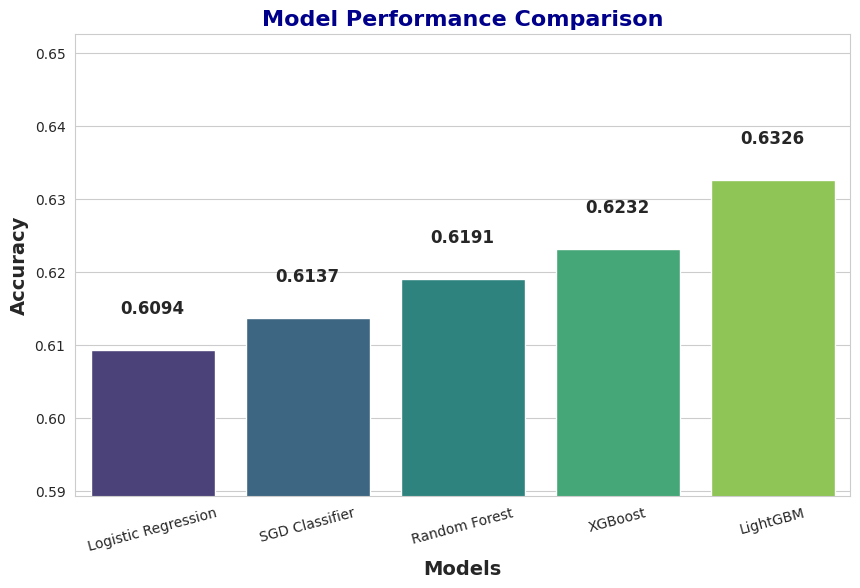

In [46]:
# Define model names and their corresponding accuracy scores
models = ["Logistic Regression", "SGD Classifier", "Random Forest", "XGBoost", "LightGBM"]
accuracies = [logistic_accuracy, SGD_accuracy, rf_accuracy, xgb_accuracy, lgbm_accuracy]

# Set figure size and style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Creating barplot
ax = sns.barplot(x=models, y=accuracies, palette="viridis")

# Adding accuracy values on top of the bars
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.005, f"{value:.4f}", ha='center', fontsize=12, fontweight='bold')

# Customize graph appearance
plt.ylim(min(accuracies) - 0.02, max(accuracies) + 0.02)  # Adjust y-axis range
plt.xlabel("Models", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy", fontsize=14, fontweight="bold")
plt.title("Model Performance Comparison", fontsize=16, fontweight="bold", color='darkblue')

# Rotate x-axis labels for better readability
plt.xticks(rotation=15)

# Display the plot
plt.show()


**Observations:**
* *LightGBM* achieved the highest accuracy (0.6326), making it the best-performing model in this comparison.
* *XGBoost* followed closely (0.6232), showing strong performance among ensemble methods.
* *Random Forest* performed moderately (0.6191), slightly lower than XGBoost.
* *Logistic Regression* (0.6094) and *SGD Classifier* (0.6137) had the lowest accuracy, indicating that linear models may not be the best fit for this dataset.
  
**Key Takeaways:**
* *Ensemble models (LightGBM & XGBoost) outperformed traditional classifiers*, highlighting their effectiveness in handling complex patterns.
* *Linear models (Logistic Regression & SGD) underperformed*, suggesting that feature relationships may be non-linear.
* *Further improvements could involve hyperparameter tuning*, feature engineering, or alternative preprocessing methods.

# Final Submission 

In [47]:
# Define the pipeline
final_model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=30, random_state=0, n_jobs=-1))
])

# Train the model
final_model_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 40360, number of negative: 39508
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.462723 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7541
[LightGBM] [Info] Number of data points in the train set: 79868, number of used features: 2231
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505334 -> initscore=0.021336
[LightGBM] [Info] Start training from score 0.021336


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical_processing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ProductName',
                                                   'EngineVersion',
                                                   'AppVersion',
                                                   'SignatureVersion',
                                                   'PlatformType', 'Processor',
                                                   'OSVersion',
                                                   'OsPlatformSubRelease',
                                                   'OSBuildLab',
                                                   'S...
                                                   'TotalPhysicalRAMMB',
                                                   'PrimaryDisplayDiagonalInches',
                                                   'PrimaryDisplayResolutionHorizontal',
                                                   'PrimaryDisplayResolutionVertical',
                                                   'InternalBatteryNumberOfCharges',
                                                   'OSBuildNumberOnly',
                                                   'OSBuildRevisionOnly',
                                                   'OSInstallLanguageID',
                                                   'OSUILocaleID', ...])])),
                ('classifier',
                 LGBMClassifier(learning_rate=0.05, max_depth=30,
                                n_estimators=400, n_jobs=-1, random_state=0))])

In [48]:

# y_pred=final_model_pipeline.predict(test_data)

# submission=pd.DataFrame({"id":range(0,test_data.shape[0]),
#                          "target":y_pred
# })

# submission.to_csv('submission.csv',index=False)